# Script for plotting EMSI

In [168]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.ticker as tck
from pathlib import Path
from scipy import signal

# Global plotting defaults used by all figures in this notebook.
FONT = {"size": 12}
matplotlib.rc("font", **FONT)
plt.rcParams["axes.labelsize"] = 14

# Directory containing the exported EMSI CSV files for this study.
folder = Path("../raw_data")


## Functions

In [233]:
def build_emsi_exp_name(c_rate="1", t_ref="298", permeability="1.9E-15", r_pos="7"):
    """Return the standardized EMSI CSV filename used in this notebook."""
    return (
        f"emsi_C_rate_{c_rate}_T_ref_{t_ref}_"
        f"Permeability_{permeability}_r_pos_{r_pos}.csv"
    )


def read_emsi_data(exp_name, skiprows=7):
    """Read one EMSI export from the study folder."""
    return pd.read_csv(folder / exp_name, skiprows=skiprows)


def get_cycle_columns(df, skip_last_cycles=None):
    """Return the cycle columns, optionally excluding incomplete cycles at the end."""
    if skip_last_cycles is not None:
        return df.columns[1:-skip_last_cycles]
    return df.columns[1:]


def get_cycle_profiles(df, skip_last_cycles=None):
    """Compute concentration profiles for each cycle."""
    y_position = df.iloc[:, 0] / 1000
    profiles = []

    for cycle_index, col in enumerate(get_cycle_columns(df, skip_last_cycles=skip_last_cycles), start=1):
        concentration = df[col] / 1000
        profiles.append((cycle_index, y_position, concentration))

    return profiles


def get_cycle_delta_c(df, skip_last_cycles=None):
    """Compute Δc_l for each cycle from the concentration profiles."""
    cycle_numbers = []
    delta_c = []

    for cycle_index, _, concentration in get_cycle_profiles(
        df, skip_last_cycles=skip_last_cycles
    ):
        cycle_numbers.append(cycle_index)
        delta_c.append(np.average(concentration[-10:]) - concentration[0])

    return np.array(cycle_numbers), np.array(delta_c)


def get_cycle_colors(n_lines):
    """Return the colormap values used to represent cycle number."""
    cmap = plt.get_cmap("berlin", int(n_lines * 2.1))
    return np.array([cmap(i) for i in range(cmap.N)])


def plot_emsi_single(df, skip_last_cycles=None, ax=None, details=True, numbering=None):
    """Plot electrolyte concentration profiles for the selected EMSI cycles."""
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

    profiles = get_cycle_profiles(df, skip_last_cycles=skip_last_cycles)
    colors = get_cycle_colors(len(profiles))

    for cycle_index, y_position, concentration in profiles:
        # Label only the first and last cycle to keep the legend compact.
        if cycle_index == 1 or cycle_index == len(profiles):
            ax.plot(concentration, y_position, label=cycle_index, color=colors[cycle_index - 1])
        else:
            ax.plot(concentration, y_position, color=colors[cycle_index - 1])

    if details:
        ax.set_ylabel(r"$y$ [mm]")
    ax.legend(title="Cycle nr", loc="lower right")
    ax.set_xlabel(r"$c_\text{l}$ [mol/L]")
    ax.grid(alpha=0.5)
    ax.grid(which="minor", alpha=0.5)
    ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.set_yticks(np.arange(0, 30.1, 10))
    ax.set_ylim(0, 30)
    if numbering is not None:
        ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")

    plt.tight_layout()


def plot_emsi_cdiff(df, skip_last_cycles=None, ax=None, details=True, numbering=None):
    """Plot Δc_l for one EMSI case, colored by cycle number."""
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

    cycle_nr, delta_c = get_cycle_delta_c(df, skip_last_cycles=skip_last_cycles)
    colors = get_cycle_colors(len(cycle_nr))

    ax.scatter(cycle_nr, delta_c, c=colors[cycle_nr])
    ax.set_xlabel("Cycle number")
    ax.set_ylabel(r"$\Delta c_\text{l}$ [mol/L]")
    ax.grid(alpha=0.5)
    ax.grid(which="minor", alpha=0.5)
    ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.set_xticks(np.arange(0, 40.1, 10))
    ax.set_xlim(0, 39)
    if numbering is not None:
        ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
    plt.tight_layout()
    return ax


def plot_emsi_cdiff2(df, skip_last_cycles=None, ax=None, details=True, label=None, numbering=None):
    """Plot Δc_l for one EMSI case as a scatter/line pair for comparisons."""
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

    cycle_nr, delta_c = get_cycle_delta_c(df, skip_last_cycles=skip_last_cycles)

    ax.scatter(cycle_nr, delta_c, label=label, marker=".", linewidth=2)
    ax.plot(cycle_nr[:38], delta_c[:38], "-", alpha=0.2)
    ax.set_xlabel("Cycle number")
    ax.set_ylabel(r"$\Delta c_\text{l}$ [mol/L]")
    ax.grid(alpha=0.5)
    ax.grid(which="minor", alpha=0.5)
    ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.set_xticks(np.arange(0, 40.1, 10))
    ax.set_xlim(0, 39)
    if numbering is not None:
        ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
    plt.tight_layout()


## Plot one EMSI figure and one deltaC figure
##### The in-plane salt concentration gradient builds up incrementally over the course of 40 cycles, the bottom plot shows the center-to-edge salt concentration difference. A 3-day rest allows the inhomogenous salt conentration to relax significantly

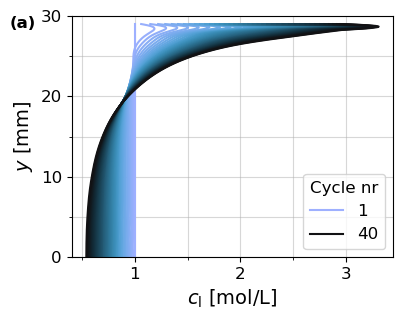

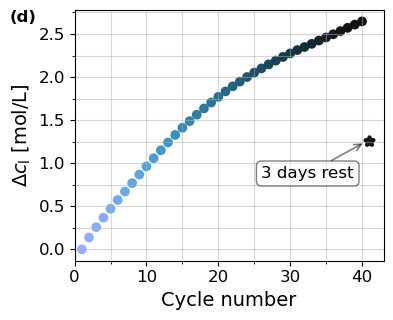

In [277]:
exp_name = build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="7", t_ref="298")
df = read_emsi_data(exp_name)

# Plot the concentration profiles for the reference 1C case.
plot_emsi_single(df, skip_last_cycles=2, numbering=(-0.18, "(a)"))
plt.savefig(f"../plots/{Path(exp_name).stem}.png", format="png", dpi=500)

# Plot Δc_l for the same case and annotate the recovery after a rest period.
ax = plot_emsi_cdiff(df, skip_last_cycles=2, numbering=(-9, "(d)"))

colors = get_cycle_colors(43)
ax.scatter(41, 1.2568, marker="*", linewidth=3, color=colors[41], alpha=1) #Extracted from a separate calculation

xy = (40.1, 1.23)
xytext = (26, 0.88)

plt.annotate(
    "3 days rest",
    xy=xy,
    xytext=xytext,
    textcoords="data",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
        shrinkA=0,
        shrinkB=0,
        alpha=0.5,
    ),
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="black",
        alpha=0.5,
    ),
    ha="left",
    va="center",
)

plt.xlim(0, 43)
plt.savefig(f"../plots/{Path(exp_name).stem}_cdiff.png", format="png", dpi=500)


## Plot EMSI vs C-rate
##### The center-to-edge concentration difference vs cycle number shows the build-up of EMSI over 40 cycles at all C-rates, with higher C-rates resulting in larger inhomogeneity

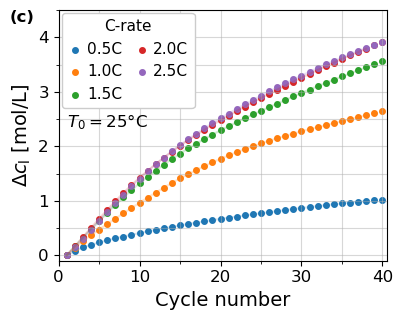

In [239]:
fig, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

# Compare Δc_l across C-rates at fixed temperature, permeability, and radial position.
comparison_cases = [
    (build_emsi_exp_name(c_rate="0.5", permeability="1.9E-15", r_pos="7", t_ref="298"), "0.5C"),
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="7", t_ref="298"), "1.0C"),
    (build_emsi_exp_name(c_rate="1.5", permeability="1.9E-15", r_pos="7", t_ref="298"), "1.5C"),
    (build_emsi_exp_name(c_rate="2", permeability="1.9E-15", r_pos="7", t_ref="298"), "2.0C"),
    (build_emsi_exp_name(c_rate="2.5", permeability="1.9E-15", r_pos="7", t_ref="298"), "2.5C"),
]

for exp_name, label in comparison_cases:
    df = read_emsi_data(exp_name)
    plot_emsi_cdiff2(df, skip_last_cycles=None, ax=ax, label=label)

ax.legend(
    framealpha=1,
    markerscale=1,
    handletextpad=0.25,
    handlelength=1,
    ncols=2,
    columnspacing=0.8,
    title="C-rate",
    fontsize=11,
    title_fontsize=11,
    borderaxespad=0.2,
)
ax.set_xlim(0, 40.6)
ax.set_yticks(np.arange(0, 4.1, 1))
ax.set_ylim(-0.1, 4.5)
ax.text(1, 2.35, r"$T_\text{0}=25\degree$C", c="black")

numbering = (-6, "(c)")
if numbering is not None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")

plt.tight_layout()
plt.savefig("../plots/emsi_vs_C_rate_cdiff.png", format="png", dpi=500)


## Plot EMSI vs temperature
##### The center-to-edge concentration difference for different temperatures shows that lower temperature leads to amplified EMSI-effect

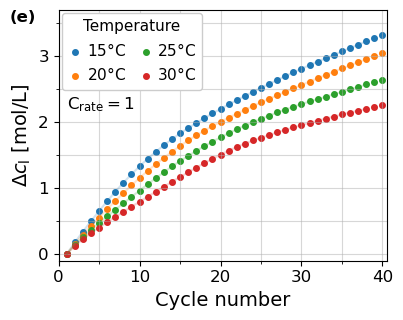

In [242]:
# 1C -- temperature

fig, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

# Compare Δc_l across temperatures at fixed 1C operation.
temperature_cases = [
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="7", t_ref="288"), r"$15 \degree$C"),
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="7", t_ref="293"), r"$20 \degree$C"),
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="7", t_ref="298"), r"$25 \degree$C"),
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="7", t_ref="303"), r"$30 \degree$C"),
]

for exp_name, label in temperature_cases:
    df = read_emsi_data(exp_name)
    plot_emsi_cdiff2(df, skip_last_cycles=None, ax=ax, label=label)

ax.legend(
    framealpha=1,
    markerscale=1,
    handletextpad=0.25,
    handlelength=1,
    ncols=2,
    columnspacing=0.8,
    title="Temperature",
    fontsize=11,
    title_fontsize=11,
    borderaxespad=0.2,
    loc="upper left",
)
ax.set_xlim(0, 40.6)
ax.set_ylim(-0.1, 3.7)
ax.set_yticks(np.arange(0, 3.1, 1))

numbering = (-6, "(e)")
if numbering is not None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
ax.text(1, 2.2, r"C$_\text{rate}$$=1$", c="black")

plt.tight_layout()
plt.savefig("../plots/emsi_vs_temperature_cdiff.png", format="png", dpi=500)


## Plot EMSI vs Rpos
##### The center-to-edge concentration difference at different radial positions in the cylindrical jelly roll between the inner (R=2mm) and outer (R=9mm) radius. The EMSI-effect is amplified towards R=4.4mm due to higher mechanical stack pressure.

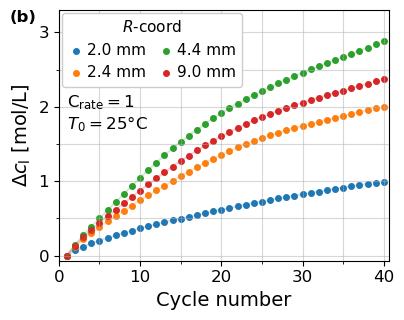

In [245]:
# 1C -- rpos

fig, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

# Compare Δc_l across radial positions at fixed 1C operation.
rpos_cases = [
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="2", t_ref="298"), "2.0 mm"),
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="2.4", t_ref="298"), "2.4 mm"),
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="4.4", t_ref="298"), "4.4 mm"),
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="9", t_ref="298"), "9.0 mm"),
]

for exp_name, label in rpos_cases:
    df = read_emsi_data(exp_name)
    plot_emsi_cdiff2(df, skip_last_cycles=None, ax=ax, label=label)

ax.legend(
    title=r"$R$-coord",
    fontsize=11,
    title_fontsize=11,
    borderaxespad=0.2,
    framealpha=1,
    markerscale=1,
    handletextpad=0.25,
    handlelength=1,
    ncols=2,
    columnspacing=0.8,
)
ax.set_xlim(0, 40.6)
ax.set_ylim(-0.07, 3.3)
ax.set_yticks(np.arange(0, 3.1, 1))
ax.text(1, 1.69, r"C$_\text{rate}$$=1$" "\n" r"$T_\text{0}=25\degree$C", c="black")
numbering = (-6, "(b)")
if numbering is not None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")

plt.tight_layout()
plt.savefig("../plots/emsi_vs_r_pos_cdiff.png", format="png", dpi=500)


## Plot EMSI vs permeability
##### The center-to-edge concentration difference for different anode permeabilities. Equal anode-and-cathode permeability (3.0E-15m^2) results in no EMSI. Higher anode permeability leads to "classical" EMSI and lower anode permeability leads to "inverse" EMSI

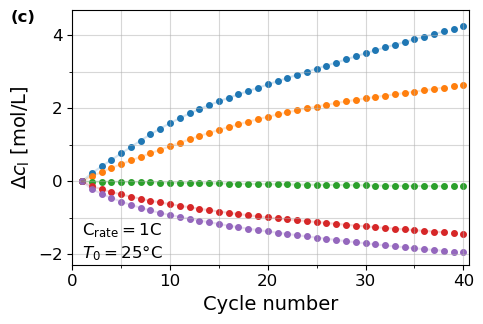

In [282]:
# 1C -- permeability
fig, ax = plt.subplots(1, 1, figsize=(5, 3.4))

# Compare Δc_l across anode in-plane permeability values.
permeability_cases = [
    (build_emsi_exp_name(c_rate="1", permeability="1.5E-15", r_pos="7", t_ref="298"), r"1.5E-15 $\text{m}^2$"),
    (build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="7", t_ref="298"), r"1.9E-15 $\text{m}^2$"),
    (build_emsi_exp_name(c_rate="1", permeability="3E-15", r_pos="7", t_ref="298"), r"3.0E-15 $\text{m}^2$"),
    (build_emsi_exp_name(c_rate="1", permeability="4.5E-15", r_pos="7", t_ref="298"), r"4.5E-15 $\text{m}^2$"),
    (build_emsi_exp_name(c_rate="1", permeability="6E-15", r_pos="7", t_ref="298"), r"6.0E-15 $\text{m}^2$"),
]

for exp_name, label in permeability_cases:
    df = read_emsi_data(exp_name)
    plot_emsi_cdiff2(df, skip_last_cycles=None, ax=ax, label=label)

ax.set_yticks(np.arange(-2, 4.1, 2))
ax.set_xlim(0, 40.6)
ax.text(1, -2.1, r"C$_\text{rate}$$=1$C" "\n" r"$T_\text{0}=25\degree$C", c="black")

numbering = (-6.3, "(c)")
if numbering is not None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")

plt.tight_layout()
plt.savefig("../plots/emsi_vs_permeability_cdiff.png", format="png", dpi=500)


## EMSI for a single permeability (with y-axis label)
##### Salt concentration profile for different anode permeabilities shows the "classical" and "inverse" EMSI in more detail

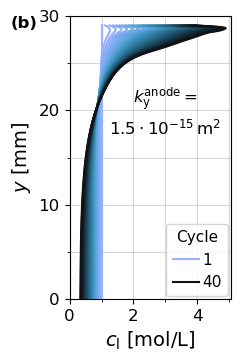

In [284]:
exp_name = build_emsi_exp_name(c_rate="1", permeability="1.5E-15", r_pos="7", t_ref="298")

fig, ax = plt.subplots(1, 1, figsize=(2.57, 3.78))
df = read_emsi_data(exp_name)
plot_emsi_single(df, skip_last_cycles=2, ax=ax, details=True)
plt.xlim(0, 5.05)
ax.text(3, 17.5, r"$k^\text{anode}_\text{y}=$" "\n" r"$1.5 \cdot 10^{-15}\,\text{m}^2$", ha="center")
ax.legend(
    title="Cycle",
    loc="lower right",
    fontsize=11,
    title_fontsize=11,
    borderaxespad=0.2,
    markerscale=1,
    handletextpad=0.25,
    handlelength=1.7,
    ncols=1,
    columnspacing=0.8,
)

numbering = (-1.85, "(b)")
if numbering is not None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")

plt.tight_layout()
plt.savefig(f"../plots/{Path(exp_name).stem}.png", format="png", dpi=500)


## EMSI for a single permeability (without y-axis label)

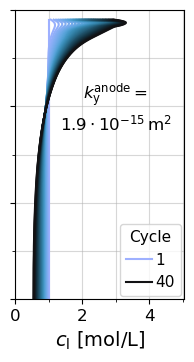

In [287]:
exp_name = build_emsi_exp_name(c_rate="1", permeability="1.9E-15", r_pos="7", t_ref="298")

fig, ax = plt.subplots(1, 1, figsize=(2.142, 3.78))
df = read_emsi_data(exp_name)
plot_emsi_single(df, skip_last_cycles=2, ax=ax, details=False)
plt.xlim(0, 5.05)
ax.text(3, 17.5, r"$k^\text{anode}_\text{y}=$" "\n" r"$1.9 \cdot 10^{-15}\,\text{m}^2$", ha="center")
ax.set_yticklabels("")
ax.legend(
    title="Cycle",
    loc="lower right",
    fontsize=11,
    title_fontsize=11,
    borderaxespad=0.2,
    markerscale=1,
    handletextpad=0.25,
    handlelength=1.7,
    ncols=1,
    columnspacing=0.8,
)

plt.tight_layout()
plt.savefig(f"../plots/{Path(exp_name).stem}_small.png", format="png", dpi=500)


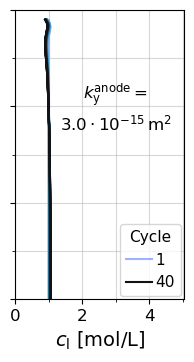

In [289]:
exp_name = build_emsi_exp_name(c_rate="1", permeability="3E-15", r_pos="7", t_ref="298")

fig, ax = plt.subplots(1, 1, figsize=(2.142, 3.78))
df = read_emsi_data(exp_name)
plot_emsi_single(df, skip_last_cycles=2, ax=ax, details=False)
plt.xlim(0, 5.05)
#ax.text(1.58, 17.5, r"$k^\text{anode}_\text{y}=$" "\n" r"$3.0 \cdot 10^{-15}\,\text{m}^2$", ha="center")
ax.text(3, 17.5, r"$k^\text{anode}_\text{y}=$" "\n" r"$3.0 \cdot 10^{-15}\,\text{m}^2$", ha="center")
ax.set_yticklabels("")
ax.legend(
    title="Cycle",
    loc="lower right",
    fontsize=11,
    title_fontsize=11,
    borderaxespad=0.2,
    markerscale=1,
    handletextpad=0.25,
    handlelength=1.7,
    ncols=1,
    columnspacing=0.8,
)

plt.tight_layout()
plt.savefig(f"../plots/{Path(exp_name).stem}.png", format="png", dpi=500)


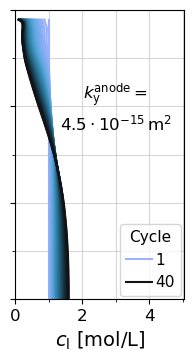

In [291]:
exp_name = build_emsi_exp_name(c_rate="1", permeability="4.5E-15", r_pos="7", t_ref="298")

fig, ax = plt.subplots(1, 1, figsize=(2.142, 3.78))
df = read_emsi_data(exp_name)
plot_emsi_single(df, skip_last_cycles=2, ax=ax, details=False)
plt.xlim(0, 5.05)
ax.text(3, 17.5, r"$k^\text{anode}_\text{y}=$" "\n" r"$4.5 \cdot 10^{-15}\,\text{m}^2$", ha="center")
ax.set_yticklabels("")
ax.legend(
    title="Cycle",
    loc="lower right",
    fontsize=11,
    title_fontsize=11,
    borderaxespad=0.2,
    markerscale=1,
    handletextpad=0.25,
    handlelength=1.7,
    ncols=1,
    columnspacing=0.8,
)

plt.tight_layout()
plt.savefig(f"../plots/{Path(exp_name).stem}.png", format="png", dpi=500)


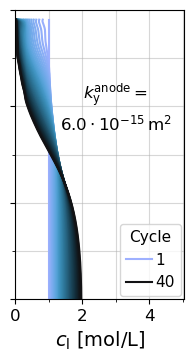

In [293]:
exp_name = build_emsi_exp_name(c_rate="1", permeability="6E-15", r_pos="7", t_ref="298")

fig, ax = plt.subplots(1, 1, figsize=(2.142, 3.78))
df = read_emsi_data(exp_name)
plot_emsi_single(df, skip_last_cycles=1, ax=ax, details=False)
plt.xlim(0, 5.05)
ax.text(3, 17.5, r"$k^\text{anode}_\text{y}=$" "\n" r"$6.0 \cdot 10^{-15}\,\text{m}^2$", ha="center")
ax.set_yticklabels("")
ax.legend(
    title="Cycle",
    loc="lower right",
    fontsize=11,
    title_fontsize=11,
    borderaxespad=0.2,
    markerscale=1,
    handletextpad=0.25,
    handlelength=1.7,
    ncols=1,
    columnspacing=0.8,
)

plt.tight_layout()
plt.savefig(f"../plots/{Path(exp_name).stem}.png", format="png", dpi=500)
